# LSCI 220 Assignment 1
## Dominic Kelly, Id 198511370

# Introduction
Rip It Up was a New Zealand music magazine that was launched in 1977 and finally ceased publication in 2015. It was the closest thing that the New Zealand contemporary music scene had to a *New Musical Express* or *Rolling Stone*. In 1988, John Dix wrote in Stranded In Paradise (a history of New Zealand Rock 'n Roll) "New Zealand's best promotional outlet for what's happening out there in the real world of rock'n'roll is neither radio nor television, but *Rip It Up*, a monthly freebie that refuses to die."

On November 11, 2025, it was announced that the Papers Past website now holds more than 20 years of free, searchable and downloadable [content](https://paperspast.natlib.govt.nz/periodicals/rip-it-up) from Rip It Up for the years 1977-1998.

I downloaded all the album reviews for Rip It Up's first five months of publication (June - October 1977) and for the five months starting on its 20th anniversary.

I made sure that each review's metadata (artist, album title etc) was formatted consistently. Since Papers Past provides an image of the printed page as well as the generated text, I corrected any errors that I could tell had been created during the scanning process, but *not* grammatical or spelling errors that were apparent in the original.

In [39]:
# some preliminary imports, setting up static data etc
from ast import pattern
import nltk
import string
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

from enum import Enum

class Year(Enum):
    Y1977 = 0
    Y1997 = 1
    R1997 = 2

punctuation_set = set(string.punctuation)

# additional punctuation are pieces of text that I found were appearing in the results 
# that I would like to have been removed with other punctuation
additional_punctuation = set(["'s", "'m", "'", '.', '"', "n't","'ve",
                              '’', '“', '”', '’;', '’’', '.)', '("',
                              '–', '—', '...', '``', "''", '‘', ',"',
                              '•', '”.', '",', '”,', '.):', '":', '’)',
                              '.”', ".'", '’,','’),', '–,', '—,', '’.', 
                              '(‘', '".', ').', '."', "')", '!!',
                              '")', '"),', '").', '";', '.’',
                              "',", '’).', "-'", '--', '?"'])

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('wordnet')
nltk.download('omw-1.4') 

lemmatizer = WordNetLemmatizer()
corpus_root = '.'  # Directory containing text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
tokeniser = nltk.tokenize.WordPunctTokenizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


The ```do_scrubbing()``` function below does five types of pre-processing that I want to apply to the corpora. By default all are applied, which is how it is used below.

In [40]:
# define a few functions.

def do_scrubbing(tokens: list, remove_punctuation=True, remove_additional_puctuation=True, remove_stopwords=True, lowercase=True, lemmatize=True) -> list:
    # Most of the cleaning out of punctuation, stopwords, plural forms etc, all in one place.
    print("Initial token count:", len(tokens))
    if lowercase:
        tokens = [token.lower() for token in tokens]
    if (remove_punctuation):
        tokens = [word for word in tokens if word not in punctuation_set]
        # tokens = [token.translate(str.maketrans('', '', string.punctuation)) for token in tokens]

    if remove_additional_puctuation:
        tokens = [word for word in tokens if word not in additional_punctuation]

    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    print("Final token count after scrubbing:", len(tokens))
    return tokens

# for analysing the text of the reviews, I prefer to exclude the headers that contain album and artist names, record labels and reviewer names
def remove_header_lines(body: str, pattern: str) -> str:
    lines = body.split('\n')
    reg_exp = re.compile(pattern)
    cleaned_lines = [line for line in lines if not reg_exp.search(line)]
    return '\n'.join(cleaned_lines)

def draw_wordcloud(frequencies: FreqDist, title: str):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(frequencies.most_common(20)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") # Turn off the axis labels
    plt.title(title)
    plt.show()

def normalise_frequencies(frequencies: FreqDist, token_count: int) -> FreqDist:
    normalized_frequencies = FreqDist()
    for word, freq in frequencies.items():
        norm_freq = freq / token_count * 100
        normalized_frequencies[word] = norm_freq
    return normalized_frequencies

In [42]:
# now the actual work

corpus = PlaintextCorpusReader(corpus_root, file_pattern)

raw_review_corpus = [None, None, None]
review_corpus = [None, None, None]
review_tokens = [None, None, None]
scrubbed_tokens = [None, None, None]
frequencies = [None, None, None]
normalised_frequencies = [None, None, None]

# Access the text

raw_review_corpus[Year.Y1977.value] = corpus.raw(['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt', 'RECORDS 77.11.01.txt', 'RECORDS 77.12.01.txt'])
raw_review_corpus[Year.Y1997.value] = corpus.raw(['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.txt', 'ALBUMS 97.09.01.txt', 'ALBUMS 97.10.01.txt', 'ALBUMS 97.11.01.txt', 'ALBUMS 97.12.01.txt'])
raw_review_corpus[Year.R1997.value] = corpus.raw(['RS97.07.10.txt', 'RS97.08.07.txt', 'RS97.08.21.txt', 'RS97.09.04.txt', 'RS97.09.18.txt', 'RS97.10.02.txt', 'RS97.10.16.txt'])

for year in [Year.Y1977.value, Year.Y1997.value, Year.R1997.value]:
    review_corpus[year] = remove_header_lines(raw_review_corpus[year], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
    review_tokens[year] = tokeniser.tokenize(review_corpus[year])
    scrubbed_tokens[year] = do_scrubbing(review_tokens[year])
    

Initial token count: 38687
Final token count after scrubbing: 17578
Initial token count: 55414
Final token count after scrubbing: 25736
Initial token count: 38332
Final token count after scrubbing: 18784


Before looking at frequencies, a few simple metrics:

In [43]:
from nltk.text import Text
import pandas as pd
raw_review_tokens = [None, None, None]
headings = ['Year', 'Token Count', 'Review Count', 'Paragraph Count', 'Paragraphs per Review', 'Tokens per Review', 'TTR']
data = []
for year in [Year.Y1977.value, Year.Y1997.value, Year.R1997.value]:
    token_type_count = len(set(scrubbed_tokens[year]))
    token_count = len(scrubbed_tokens[year])
    TTR = token_type_count / token_count
    paragraphs = review_corpus[year].split('\n')
    num_paragraphs = len(paragraphs)
    tokens_per_paragraph = token_count / num_paragraphs
    raw_review_tokens[year] = tokeniser.tokenize(raw_review_corpus[year])
    num_non_reviews = review_tokens[year].count('reviewed')
    num_reviews = raw_review_tokens[year].count('Reviewed') - num_non_reviews
    paragraphs_per_review = num_paragraphs / num_reviews
    tokens_per_review = token_count / num_reviews
    data.append([year, token_count, num_reviews, num_paragraphs, paragraphs_per_review, tokens_per_review, TTR])

df = pd.DataFrame(data, columns=headings )
print(df)

   Year  Token Count  Review Count  Paragraph Count  Paragraphs per Review  \
0     0        17578            83              592               7.132530   
1     1        25736           233              511               2.193133   
2     2        18784           105              319               3.038095   

   Tokens per Review       TTR  
0         211.783133  0.297019  
1         110.454936  0.300163  
2         178.895238  0.366163  


This analysis seems to be saying that by 1997 there were nearly three times as many reviews in each publication, but each one was half as long, with far fewer paragraphs.

The Type/Token Ratio went up a little.

Now some **Frequencies**, with word clouds to aid with visualisation.

Most common words in Y1977 (normalised frequencies):
  album: 1.6%
  song: 1.1%
  one: 0.79%
  record: 0.76%
  band: 0.67%
  like: 0.66%
  music: 0.57%
  rock: 0.56%
  good: 0.52%
  new: 0.43%
  sound: 0.42%
  well: 0.4%
  time: 0.39%
  track: 0.38%
  vocal: 0.38%
  two: 0.35%
  little: 0.35%
  first: 0.34%
  love: 0.34%
  guitar: 0.33%


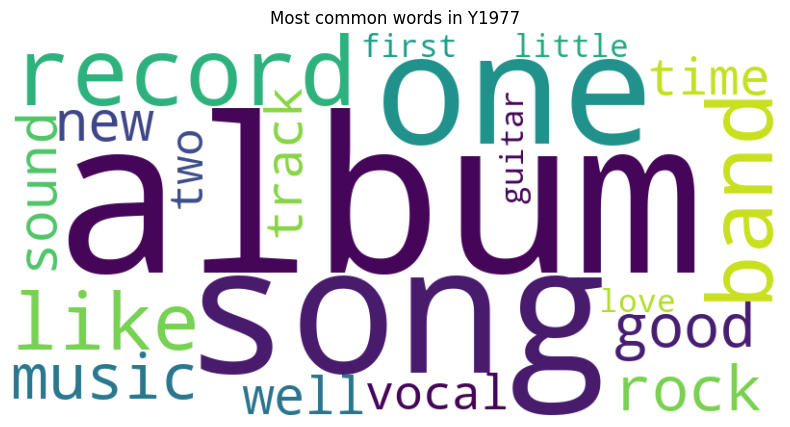

Most common words in Y1997 (normalised frequencies):
  album: 1.4%
  like: 0.81%
  song: 0.76%
  sound: 0.59%
  one: 0.57%
  band: 0.56%
  rock: 0.54%
  track: 0.52%
  new: 0.4%
  guitar: 0.36%
  good: 0.36%
  time: 0.35%
  vocal: 0.32%
  get: 0.31%
  music: 0.3%
  much: 0.3%
  year: 0.3%
  first: 0.28%
  well: 0.27%
  pop: 0.27%


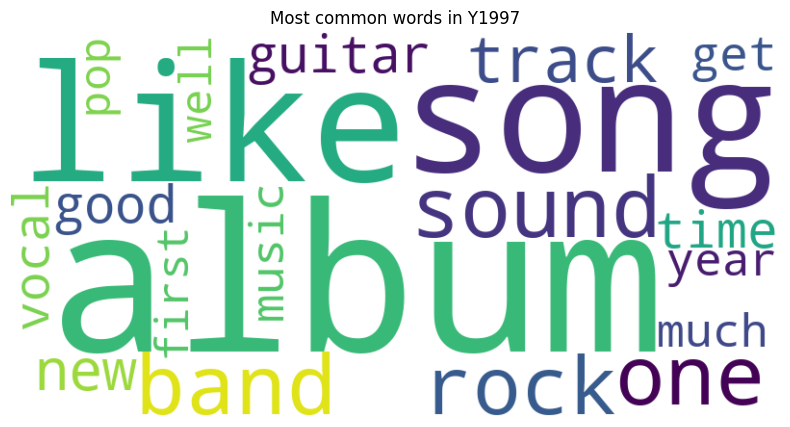

Most common words in R1997 (normalised frequencies):
  album: 0.85%
  song: 0.8%
  like: 0.75%
  band: 0.47%
  music: 0.46%
  track: 0.46%
  rock: 0.46%
  sound: 0.44%
  guitar: 0.39%
  new: 0.35%
  pop: 0.33%
  one: 0.32%
  time: 0.31%
  love: 0.29%
  year: 0.28%
  make: 0.26%
  still: 0.24%
  even: 0.24%
  voice: 0.22%
  get: 0.22%


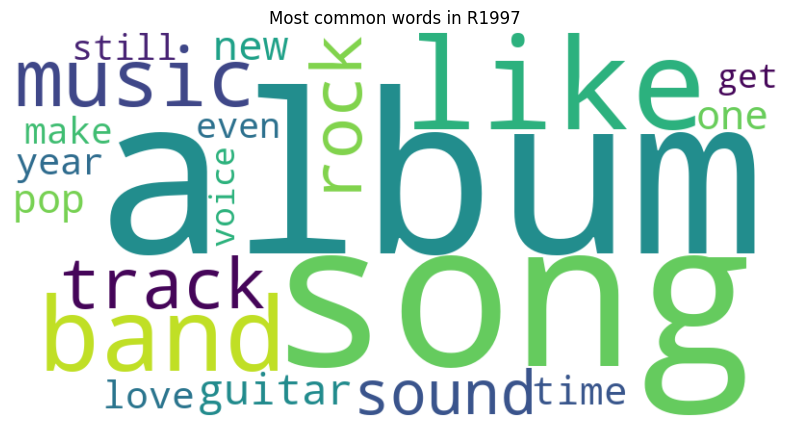

In [44]:

for year in [Year.Y1977.value, Year.Y1997.value, Year.R1997.value]:
    frequencies[year] = FreqDist(scrubbed_tokens[year])
    token_count = len(scrubbed_tokens[year])
    # print(f"Most common words in {Year(year).name} (absolute frequencies):")
        # for word, freq in frequencies[year].most_common(20):
        #     print(f"  {word}: {freq}")
    # normalising becomes important when comparing corpora of different sizes
    print(f"Most common words in {Year(year).name} (normalised frequencies):")
    normalised_frequencies[year] = normalise_frequencies(frequencies[year], token_count)
    for word, freq in normalised_frequencies[year].most_common(20):
        print(f"  {word}: {freq:.2}%")
    most_common = frequencies[year].most_common(20)
    draw_wordcloud(frequencies[year], f"Most common words in {Year(year).name}")


I'd like to tell what vocabulary dropped out of use between 1977 and 1997 and what replaced it.

It turns out that a whole Frequency Distribution can be subtracted from another to produce a third, listing all the differences.

  record: 0.5%
  song: 0.3%
  group: 0.3%
  music: 0.3%
  album: 0.2%
  one: 0.2%
  arrangement: 0.2%
  side: 0.2%
  good: 0.2%
  never: 0.2%
  however: 0.2%
  play: 0.1%
  two: 0.1%
  little: 0.1%
  studio: 0.1%
  well: 0.1%
  lyric: 0.1%
  recording: 0.1%
  work: 0.1%
  concert: 0.1%


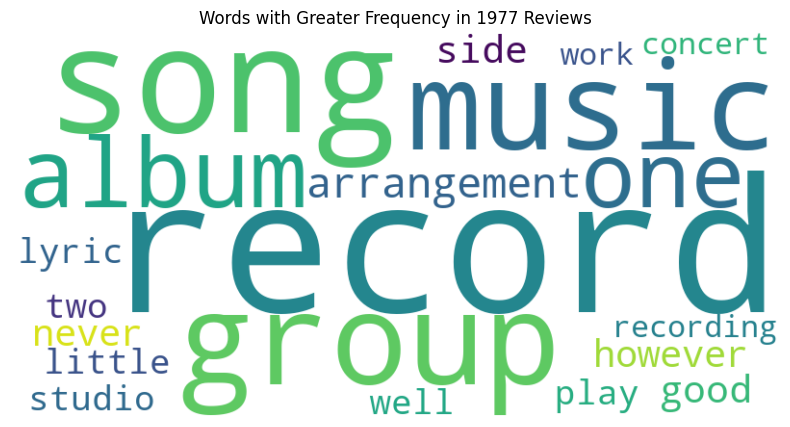

  sound: 0.2%
  like: 0.2%
  track: 0.1%
  release: 0.1%
  pop: 0.1%
  punk: 0.1%
  beat: 0.1%
  label: 0.1%
  disc: 0.1%
  big: 0.1%
  yeah: 0.1%
  thing: 0.1%
  much: 0.1%
  hop: 0.1%
  noise: 0.1%
  sample: 0.1%
  come: 0.1%
  metal: 0.1%
  soundtrack: 0.1%
  ),: 0.1%


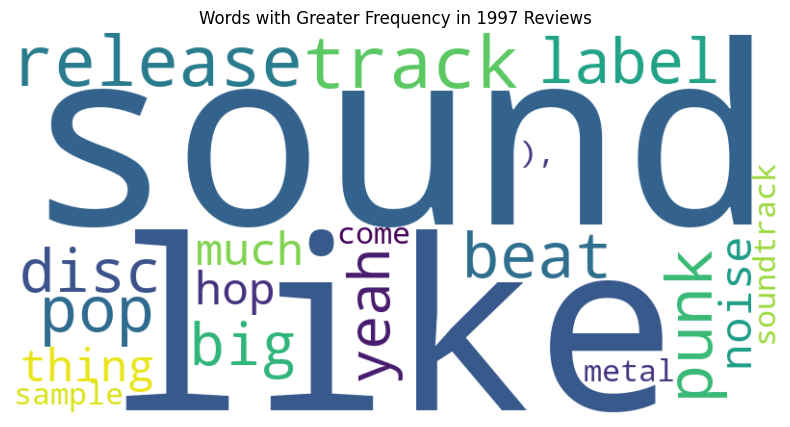

In [45]:

more_frequent_in_77 = normalised_frequencies[Year.Y1977.value] - normalised_frequencies[Year.Y1997.value]  # Words more common in first corpus
more_frequent_in_97 = normalised_frequencies[Year.Y1997.value] - normalised_frequencies[Year.Y1977.value]  # Words more common in second corpus

for word, freq in more_frequent_in_77.most_common(20):
    print(f"  {word}: {freq:.1f}%")
draw_wordcloud(FreqDist(more_frequent_in_77), "Words with Greater Frequency in 1977 Reviews")
for word, freq in more_frequent_in_97.most_common(20):
    print(f"  {word}: {freq:.1f}%")
draw_wordcloud(FreqDist(more_frequent_in_97), "Words with Greater Frequency in 1997 Reviews")

At first glance this process had produced some interesting results. But looking closer, some of the results look misleading. The word **album** dropped in frequency from 1.6% to 1.4%, and so made its way to number 6 in the list of words whose use had reduced between 1977 and 1997, even though it was still the single most frequently used word in both lists.

I concluded that even after normalising (and so accounting for any difference in sheer size of the two word lists), the differences in the frequencies over-emphasised any change for the most common words. Similarly, if a word was completely absent from one list but got a modest but meaningful amount of use in the other, it wouldn't necessarily appear at a particularly high position in this list of more frequently used words.

Some rummaging on the Internet suggested that a better way to determine the significance in change in use of a word between corpora was to calculate the **Log Likelihood**. It is [said](https://wordhoard.northwestern.edu/userman/analysis-comparewords.html) that the Log Likelihood "ratio measures the discrepancy of the the (sic) observed word frequencies from the values which we would expect to see if the word frequencies (by percentage) were the same in the two texts."

The code below works out which words generate the highest Log Likelihood values when their frequencies within the respective word lists are considered. Those whose LL value is above the threshold to be considered "highly significant" are appended to the list for the year in which they are (more significantly) present. Those words are then put in a word cloud with the LL value standing in for a frequency to determine how large to render that word.

Word with significantly changed use by Log-Likelihood scores:
  group: 66.23. From 55 to 6 appearances.
  record: 65.75. From 133 to 58 appearances.
  arrangement: 38.40. From 39 to 7 appearances.
  lofgren: 27.05. From 15 to 0 appearances.
  yeah: 26.03. From 0 to 25 appearances.
  reed: 25.67. From 18 to 1 appearances.
  however: 24.57. From 34 to 10 appearances.
  release: 23.76. From 4 to 42 appearances.
  dolly: 23.45. From 13 to 0 appearances.
  newman: 23.45. From 13 to 0 appearances.
  disc: 23.23. From 1 to 29 appearances.
  disco: 23.00. From 23 to 4 appearances.
  hip: 21.86. From 0 to 21 appearances.
  label: 21.71. From 2 to 32 appearances.
  frampton: 21.64. From 12 to 0 appearances.
  concert: 20.88. From 25 to 6 appearances.
  already: 20.82. From 0 to 20 appearances.
  hop: 20.32. From 1 to 26 appearances.
  feat: 19.84. From 11 to 0 appearances.
  miracle: 19.84. From 11 to 0 appearances.
  dj: 19.78. From 0 to 19 appearances.
  noise: 19.36. From 1 to 25 appearances.

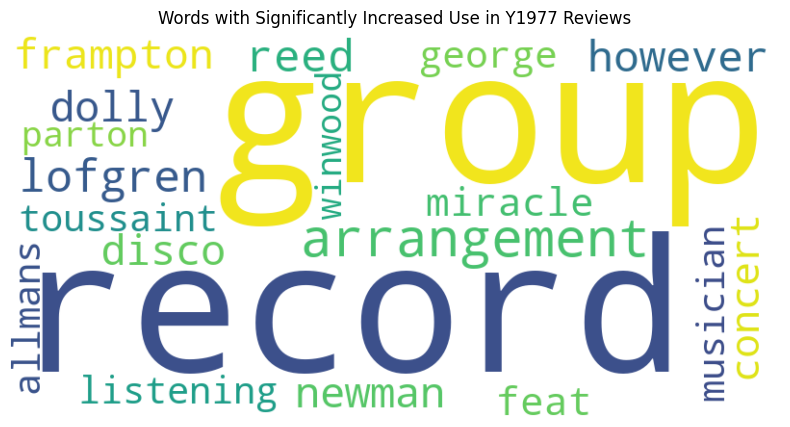

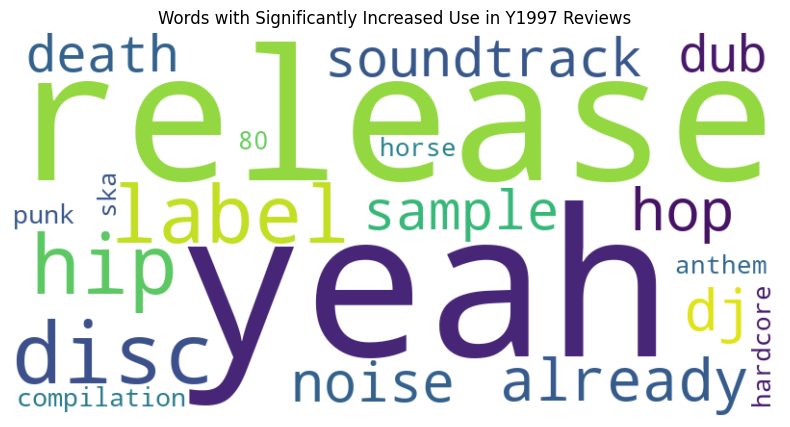

Word with significantly changed use by Log-Likelihood scores:
  record: 67.64. From 133 to 35 appearances.
  good: 49.95. From 91 to 22 appearances.
  album: 44.94. From 286 to 160 appearances.
  one: 36.64. From 139 to 61 appearances.
  hip: 33.03. From 0 to 25 appearances.
  little: 32.99. From 61 to 15 appearances.
  side: 32.92. From 51 to 10 appearances.
  dylan: 32.25. From 1 to 30 appearances.
  hop: 31.00. From 1 to 29 appearances.
  techno: 30.38. From 0 to 23 appearances.
  concert: 29.19. From 25 to 1 appearances.
  dj: 29.06. From 0 to 22 appearances.
  reed: 26.17. From 18 to 0 appearances.
  strong: 26.03. From 26 to 2 appearances.
  number: 23.38. From 36 to 7 appearances.
  average: 23.26. From 16 to 0 appearances.
  best: 22.99. From 49 to 14 appearances.
  ochs: 22.46. From 0 to 17 appearances.
  whole: 22.14. From 23 to 2 appearances.
  lofgren: 21.81. From 15 to 0 appearances.
  well: 21.49. From 70 to 28 appearances.
  however: 21.20. From 34 to 7 appearances.
  pl

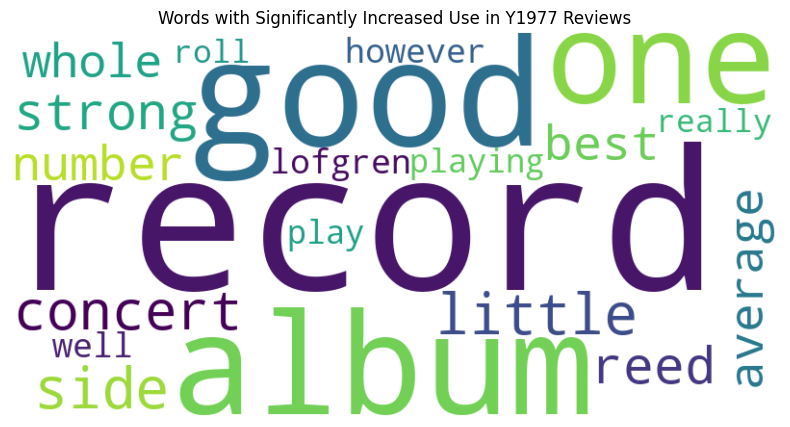

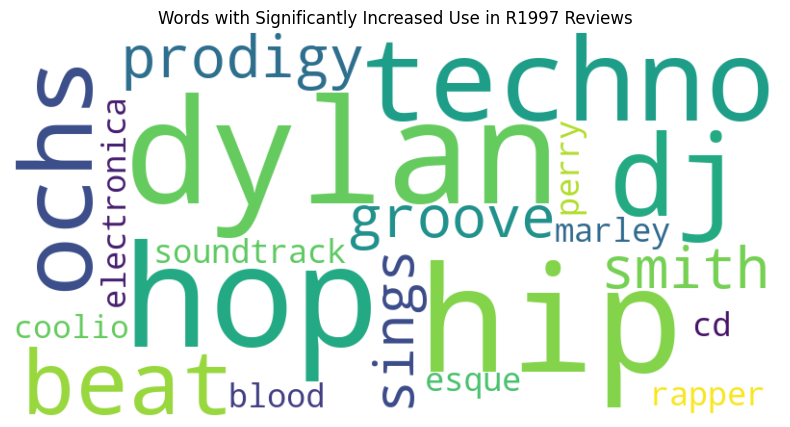

In [47]:
import math

def calculate_single_log_likelihood(a: int, b: int, c: int, d: int):
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    G_squared = 2*((a * math.log(a / E1) if a != 0 else 0) + (b * math.log(b / E2) if b != 0 else 0))
    return G_squared


def calculate_log_likelihoods(freq_1: FreqDist, word_count_1: int, freq_2: FreqDist, word_count_2: int):
    all_words = set(freq_1.keys()).union(set(freq_2.keys()))
    ll_scores = {}
    for word in all_words:
        # if (freq_1[word] > 10) | (freq_2[word] > 10):
        a = freq_1[word]
        b = freq_2[word]
        c = word_count_1
        d = word_count_2
        ll_scores[word] = calculate_single_log_likelihood(a, b, c, d)
    return ll_scores

increased_use = [[], []]

# note: back to using raw frequencies rather than normalised ones.
LLs = calculate_log_likelihoods(frequencies[Year.Y1977.value], len(scrubbed_tokens[Year.Y1977.value]), frequencies[Year.Y1997.value], len(scrubbed_tokens[Year.Y1997.value]))
sorted_LLs = sorted(LLs.items(), key=lambda x: x[1], reverse=True)
print("Word with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs:
    if (score > 6.63): # LL scores greater than 6.63 are considered highly significant
        print(f"  {word}: {score:.2f}. From {frequencies[Year.Y1977.value][word]} to {frequencies[Year.Y1997.value][word]} appearances.")
        if (normalised_frequencies[Year.Y1977.value][word] > normalised_frequencies[Year.Y1997.value][word]):
            increased_use[Year.Y1977.value].append((word, score))
        else:
            increased_use[Year.Y1997.value].append((word, score))

for year in [Year.Y1977.value, Year.Y1997.value]:
    word_freq_dist = FreqDist(dict(increased_use[year]))

    draw_wordcloud(word_freq_dist, "Words with Significantly Increased Use in " + Year(year).name + " Reviews")

increased_use = [[], [], []]

LLs = calculate_log_likelihoods(frequencies[Year.Y1977.value], len(scrubbed_tokens[Year.Y1977.value]), frequencies[Year.R1997.value], len(scrubbed_tokens[Year.R1997.value]))
sorted_LLs = sorted(LLs.items(), key=lambda x: x[1], reverse=True)
print("Word with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs:
    if (score > 6.63): # LL scores greater than 6.63 are considered highly significant
        print(f"  {word}: {score:.2f}. From {frequencies[Year.Y1977.value][word]} to {frequencies[Year.R1997.value][word]} appearances.")
        if (normalised_frequencies[Year.Y1977.value][word] > normalised_frequencies[Year.R1997.value][word]):
            increased_use[Year.Y1977.value].append((word, score))
        else:
            increased_use[Year.R1997.value].append((word, score))
for year in [Year.Y1977.value, Year.R1997.value]:
    word_freq_dist = FreqDist(dict(increased_use[year]))

    draw_wordcloud(word_freq_dist, "Words with Significantly Increased Use in " + Year(year).name + " Reviews")    

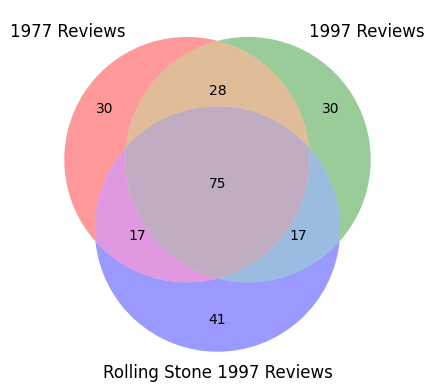

In [50]:
from matplotlib_venn import venn3

high_freq_tokens = [{}, {}, {}]

for year in [Year.Y1977.value, Year.Y1997.value, Year.R1997.value]:
    high_freq_tokens[year] = set([word for (word, freq) in frequencies[year].most_common(150)])

venn3([high_freq_tokens[Year.Y1977.value], high_freq_tokens[Year.Y1997.value], high_freq_tokens[Year.R1997.value]], 
      set_labels = ('1977 Reviews', '1997 Reviews', 'Rolling Stone 1997 Reviews'))
plt.show()

*Corpora created using the [Rip It Up magazine archive at Papers Past](https://paperspast.natlib.govt.nz/periodicals/rip-it-up).*
    
*This archive is licensed for non-commercial use under a Creative Commons Attribution Non-Commercial Share Alike 3.0 (CC BY-NC-SA 3.0) licence. Rip it Up is not available for commercial use without the consent of Propeller Lamont Ltd.*